# Compression Storage Analysis

This notebook compares storage usage across video compression levels by:

- matching the same video across all compression folders
- measuring file size for each version
- computing average and total storage at each compression level
- calculating percentage reduction relative to the original videos
- visualizing per-video and aggregate storage differences

In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# ============================================================
# Paths
# ============================================================
ROOT = Path("cholec80")

FOLDERS = {
    "orig": ROOT / "videos",
    "CRF18": ROOT / "videos_CRF18",
    "CRF23": ROOT / "videos_CRF23",
    "CRF28": ROOT / "videos_CRF28",
    "CRF35": ROOT / "videos_CRF35",
    "CRF51": ROOT / "videos_CRF51",
}

# ============================================================
# Helper functions
# ============================================================
VIDEO_EXTS = {".mp4", ".avi", ".mov", ".mkv", ".mpeg", ".mpg", ".m4v"}

def get_video_files(folder):
    """
    Returns a dictionary:
        {filename: full_path}
    for all video files in the folder.
    """
    folder = Path(folder)
    files = {}
    for f in folder.iterdir():
        if f.is_file() and f.suffix.lower() in VIDEO_EXTS:
            files[f.name] = f
    return files

def bytes_to_mb(x):
    return x / (1024 ** 2)

def bytes_to_gb(x):
    return x / (1024 ** 3)

In [3]:
# ============================================================
# Sanity check: count videos in each folder
# ============================================================
for label, folder in FOLDERS.items():
    files = get_video_files(folder)
    print(f"{label:>5} | {len(files):3d} videos | {folder}")

 orig |  80 videos | cholec80/videos
CRF18 |  80 videos | cholec80/videos_CRF18
CRF23 |  80 videos | cholec80/videos_CRF23
CRF28 |  80 videos | cholec80/videos_CRF28
CRF35 |  80 videos | cholec80/videos_CRF35
CRF51 |  80 videos | cholec80/videos_CRF51


In [4]:
# ============================================================
# Build per-video size table
# ============================================================
folder_files = {label: get_video_files(folder) for label, folder in FOLDERS.items()}

# Use the original folder as the reference set
orig_names = sorted(folder_files["orig"].keys())

rows = []

for video_name in orig_names:
    row = {"video": video_name}
    
    # original size
    orig_path = folder_files["orig"].get(video_name, None)
    if orig_path is None:
        continue
    
    orig_size = orig_path.stat().st_size
    row["orig_bytes"] = orig_size
    
    # compressed sizes
    for crf_label in ["CRF18", "CRF23", "CRF28", "CRF35", "CRF51"]:
        comp_path = folder_files[crf_label].get(video_name, None)
        
        if comp_path is None:
            row[f"{crf_label}_bytes"] = np.nan
            row[f"{crf_label}_pct_reduction"] = np.nan
            row[f"{crf_label}_bytes_saved"] = np.nan
        else:
            comp_size = comp_path.stat().st_size
            row[f"{crf_label}_bytes"] = comp_size
            row[f"{crf_label}_bytes_saved"] = orig_size - comp_size
            row[f"{crf_label}_pct_reduction"] = ((orig_size - comp_size) / orig_size) * 100
    
    rows.append(row)

df_sizes = pd.DataFrame(rows)

# Add MB columns for readability
df_sizes["orig_MB"] = bytes_to_mb(df_sizes["orig_bytes"])

for crf_label in ["CRF18", "CRF23", "CRF28", "CRF35", "CRF51"]:
    df_sizes[f"{crf_label}_MB"] = bytes_to_mb(df_sizes[f"{crf_label}_bytes"])
    df_sizes[f"{crf_label}_saved_MB"] = bytes_to_mb(df_sizes[f"{crf_label}_bytes_saved"])

print("Shape:", df_sizes.shape)
df_sizes.head()

Shape: (80, 28)


,video,orig_bytes,CRF18_bytes,CRF18_bytes_saved,CRF18_pct_reduction,CRF23_bytes,CRF23_bytes_saved,CRF23_pct_reduction,CRF28_bytes,CRF28_bytes_saved,...,CRF18_MB,CRF18_saved_MB,CRF23_MB,CRF23_saved_MB,CRF28_MB,CRF28_saved_MB,CRF35_MB,CRF35_saved_MB,CRF51_MB,CRF51_saved_MB
0,video01.mp4,692670114,727940058,-35269944,-5.091882,362994551,329675563,47.594888,176219575,516450539,...,694.217737,-33.636040,346.178580,314.403117,168.056083,492.525615,65.266183,595.315515,8.596094,651.985603
1,video02.mp4,1140346583,1202206070,-61859487,-5.424622,620022954,520323629,45.628552,310490187,829856396,...,1146.513052,-58.993804,591.299967,496.219281,296.106517,791.412731,116.043841,971.475407,16.195878,1071.323370
2,video03.mp4,4089518148,4518390922,-428872774,-10.487122,2312687941,1776830207,43.448400,1028828877,3060689271,...,4309.073374,-409.004950,2205.551091,1694.517333,981.167676,2918.900748,324.985051,3575.083373,42.434836,3857.633588
3,video04.mp4,552762465,579433913,-26671448,-4.825119,289309367,263453098,47.661177,141015180,411747285,...,552.591241,-25.435875,275.906913,251.248453,134.482555,392.672811,53.504554,473.650812,8.056009,519.099357
4,video05.mp4,855618558,898978775,-43360217,-5.067704,439327679,416290879,48.653793,211482463,644136095,...,857.332969,-41.351525,418.975524,397.005919,201.685393,614.296050,81.331277,734.650167,13.172969,802.808475


In [5]:
# ============================================================
# Check for missing video matches
# ============================================================
missing_summary = {}

for crf_label in ["CRF18", "CRF23", "CRF28", "CRF35", "CRF51"]:
    missing = df_sizes[f"{crf_label}_bytes"].isna().sum()
    missing_summary[crf_label] = missing

pd.Series(missing_summary, name="missing_files")

CRF18    0
CRF23    0
CRF28    0
CRF35    0
CRF51    0
Name: missing_files, dtype: int64

In [6]:
# ============================================================
# Aggregate summary
# ============================================================
summary_rows = []

orig_total_bytes = df_sizes["orig_bytes"].sum()
orig_avg_bytes = df_sizes["orig_bytes"].mean()

summary_rows.append({
    "level": "orig",
    "num_videos": df_sizes["orig_bytes"].notna().sum(),
    "avg_bytes": orig_avg_bytes,
    "avg_MB": bytes_to_mb(orig_avg_bytes),
    "avg_GB": bytes_to_gb(orig_avg_bytes),
    "total_bytes": orig_total_bytes,
    "total_MB": bytes_to_mb(orig_total_bytes),
    "total_GB": bytes_to_gb(orig_total_bytes),
    "avg_pct_reduction_vs_orig": 0.0,
    "total_pct_reduction_vs_orig": 0.0,
    "avg_bytes_saved_vs_orig": 0.0,
    "total_bytes_saved_vs_orig": 0.0,
})

for crf_label in ["CRF18", "CRF23", "CRF28", "CRF35", "CRF51"]:
    avg_bytes = df_sizes[f"{crf_label}_bytes"].mean()
    total_bytes = df_sizes[f"{crf_label}_bytes"].sum()
    
    avg_pct_reduction = df_sizes[f"{crf_label}_pct_reduction"].mean()
    total_pct_reduction = ((orig_total_bytes - total_bytes) / orig_total_bytes) * 100
    
    avg_bytes_saved = df_sizes[f"{crf_label}_bytes_saved"].mean()
    total_bytes_saved = df_sizes[f"{crf_label}_bytes_saved"].sum()
    
    summary_rows.append({
        "level": crf_label,
        "num_videos": df_sizes[f"{crf_label}_bytes"].notna().sum(),
        "avg_bytes": avg_bytes,
        "avg_MB": bytes_to_mb(avg_bytes),
        "avg_GB": bytes_to_gb(avg_bytes),
        "total_bytes": total_bytes,
        "total_MB": bytes_to_mb(total_bytes),
        "total_GB": bytes_to_gb(total_bytes),
        "avg_pct_reduction_vs_orig": avg_pct_reduction,
        "total_pct_reduction_vs_orig": total_pct_reduction,
        "avg_bytes_saved_vs_orig": avg_bytes_saved,
        "total_bytes_saved_vs_orig": total_bytes_saved,
    })

df_summary = pd.DataFrame(summary_rows)

df_summary_rounded = df_summary.copy()
for col in ["avg_MB", "avg_GB", "total_MB", "total_GB",
            "avg_pct_reduction_vs_orig", "total_pct_reduction_vs_orig"]:
    df_summary_rounded[col] = df_summary_rounded[col].round(2)

df_summary_rounded

,level,num_videos,avg_bytes,avg_MB,avg_GB,total_bytes,total_MB,total_GB,avg_pct_reduction_vs_orig,total_pct_reduction_vs_orig,avg_bytes_saved_vs_orig,total_bytes_saved_vs_orig
0,orig,80,9.365342e+08,893.15,0.87,74922735169,71451.89,69.78,0.00,0.00,0.000000e+00,0.000000e+00
1,CRF18,80,9.883555e+08,942.57,0.92,79068438955,75405.54,73.64,-5.16,-5.53,-5.182130e+07,-4.145704e+09
2,CRF23,80,4.904031e+08,467.68,0.46,39232248409,37414.79,36.54,48.27,47.64,4.461311e+08,3.569049e+10
3,CRF28,80,2.376739e+08,226.66,0.22,19013908612,18133.08,17.71,74.79,74.62,6.988603e+08,5.590883e+10
4,CRF35,80,9.489437e+07,90.50,0.09,7591549779,7239.87,7.07,89.82,89.87,8.416398e+08,6.733119e+10
5,CRF51,80,1.415899e+07,13.50,0.01,1132718847,1080.24,1.05,98.53,98.49,9.223752e+08,7.379002e+10


In [7]:
# ============================================================
# Compact presentation table
# ============================================================
display_cols = [
    "level",
    "num_videos",
    "avg_MB",
    "total_GB",
    "avg_pct_reduction_vs_orig",
    "total_pct_reduction_vs_orig",
]

df_summary_rounded[display_cols]

,level,num_videos,avg_MB,total_GB,avg_pct_reduction_vs_orig,total_pct_reduction_vs_orig
0,orig,80,893.15,69.78,0.00,0.00
1,CRF18,80,942.57,73.64,-5.16,-5.53
2,CRF23,80,467.68,36.54,48.27,47.64
3,CRF28,80,226.66,17.71,74.79,74.62
4,CRF35,80,90.50,7.07,89.82,89.87
5,CRF51,80,13.50,1.05,98.53,98.49


In [8]:
# ============================================================
# Per-video comparison table (MB)
# ============================================================
per_video_cols = [
    "video",
    "orig_MB",
    "CRF18_MB",
    "CRF23_MB",
    "CRF28_MB",
    "CRF35_MB",
    "CRF51_MB",
]

df_per_video = df_sizes[per_video_cols].copy().round(2)
df_per_video.head(20)

,video,orig_MB,CRF18_MB,CRF23_MB,CRF28_MB,CRF35_MB,CRF51_MB
0,video01.mp4,660.58,694.22,346.18,168.06,65.27,8.60
1,video02.mp4,1087.52,1146.51,591.30,296.11,116.04,16.20
2,video03.mp4,3900.07,4309.07,2205.55,981.17,324.99,42.43
3,video04.mp4,527.16,552.59,275.91,134.48,53.50,8.06
4,video05.mp4,815.98,857.33,418.98,201.69,81.33,13.17
5,video06.mp4,827.56,872.98,445.04,219.65,86.24,12.58
6,video07.mp4,2045.07,2187.94,1056.12,471.35,174.68,24.55
7,video08.mp4,408.27,428.68,210.62,105.14,44.93,7.40
8,video09.mp4,1028.37,1085.20,547.88,267.66,105.22,14.56
9,video10.mp4,569.80,594.37,299.80,152.53,64.14,9.28


In [9]:
# ============================================================
# Per-video percentage reduction table
# ============================================================
pct_cols = [
    "video",
    "CRF18_pct_reduction",
    "CRF23_pct_reduction",
    "CRF28_pct_reduction",
    "CRF35_pct_reduction",
    "CRF51_pct_reduction",
]

df_pct = df_sizes[pct_cols].copy().round(2)
df_pct.head(20)

,video,CRF18_pct_reduction,CRF23_pct_reduction,CRF28_pct_reduction,CRF35_pct_reduction,CRF51_pct_reduction
0,video01.mp4,-5.09,47.59,74.56,90.12,98.70
1,video02.mp4,-5.42,45.63,72.77,89.33,98.51
2,video03.mp4,-10.49,43.45,74.84,91.67,98.91
3,video04.mp4,-4.83,47.66,74.49,89.85,98.47
4,video05.mp4,-5.07,48.65,75.28,90.03,98.39
5,video06.mp4,-5.49,46.22,73.46,89.58,98.48
6,video07.mp4,-6.99,48.36,76.95,91.46,98.80
7,video08.mp4,-5.00,48.41,74.25,88.99,98.19
8,video09.mp4,-5.53,46.72,73.97,89.77,98.58
9,video10.mp4,-4.31,47.39,73.23,88.74,98.37


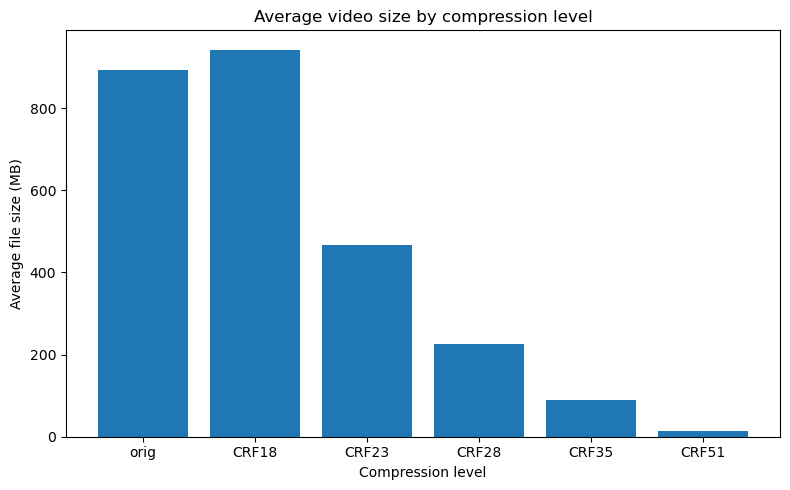

In [10]:
# ============================================================
# Plot 1: Average size per video
# ============================================================
plot_df = df_summary.copy()

plt.figure(figsize=(8, 5))
plt.bar(plot_df["level"], plot_df["avg_MB"])
plt.ylabel("Average file size (MB)")
plt.xlabel("Compression level")
plt.title("Average video size by compression level")
plt.tight_layout()
plt.show()

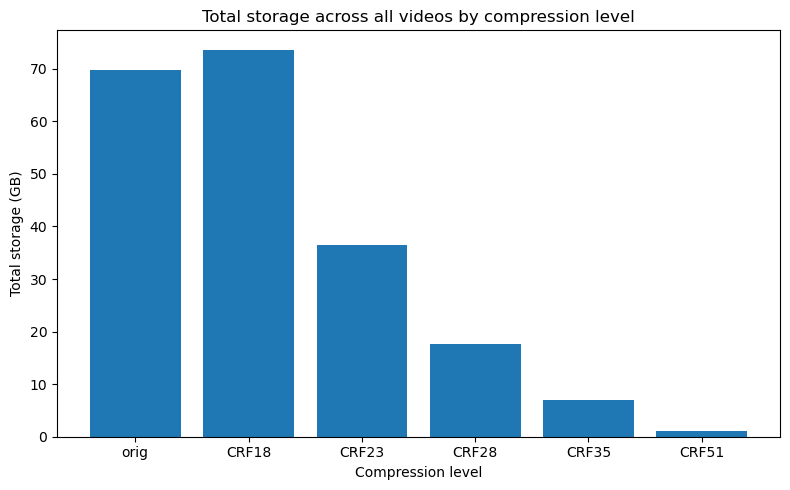

In [11]:
# ============================================================
# Plot 2: Total storage across all videos
# ============================================================
plt.figure(figsize=(8, 5))
plt.bar(df_summary["level"], df_summary["total_GB"])
plt.ylabel("Total storage (GB)")
plt.xlabel("Compression level")
plt.title("Total storage across all videos by compression level")
plt.tight_layout()
plt.show()

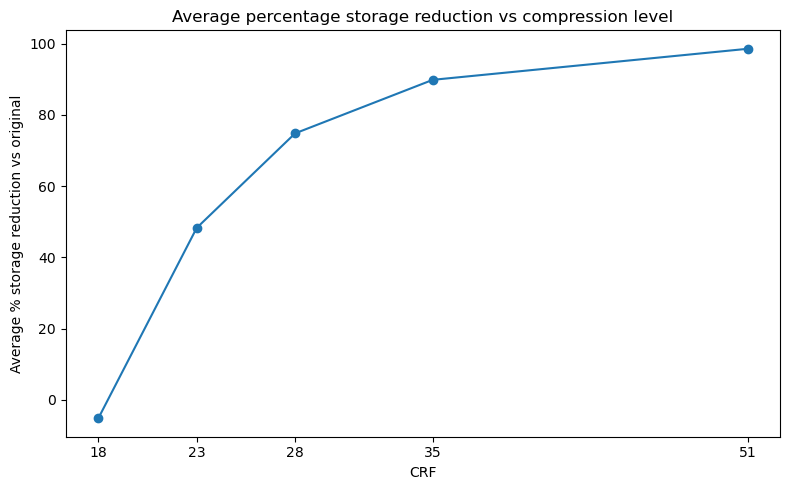

In [12]:
# ============================================================
# Plot 3: Percentage reduction vs original
# ============================================================
crf_only = df_summary[df_summary["level"] != "orig"].copy()
crf_only["crf_num"] = crf_only["level"].str.replace("CRF", "", regex=False).astype(int)

plt.figure(figsize=(8, 5))
plt.plot(crf_only["crf_num"], crf_only["avg_pct_reduction_vs_orig"], marker="o")
plt.xlabel("CRF")
plt.ylabel("Average % storage reduction vs original")
plt.title("Average percentage storage reduction vs compression level")
plt.xticks(crf_only["crf_num"])
plt.tight_layout()
plt.show()

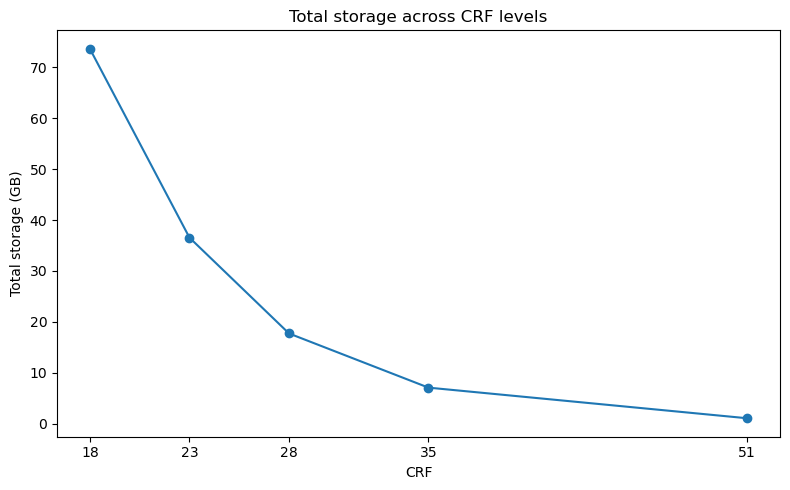

In [14]:
# ============================================================
# Plot 4: Total storage trend across CRF levels
# ============================================================
plt.figure(figsize=(8, 5))
plt.plot(crf_only["crf_num"], crf_only["total_GB"], marker="o")
plt.xlabel("CRF")
plt.ylabel("Total storage (GB)")
plt.title("Total storage across CRF levels")
plt.xticks(crf_only["crf_num"])
plt.tight_layout()
plt.show()

/var/folders/yb/s9bdcd855bj8lbpznbjmtnvm0000gn/T/ipykernel_22515/1819252936.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([box_df[col].dropna() for col in box_df.columns], labels=box_df.columns)


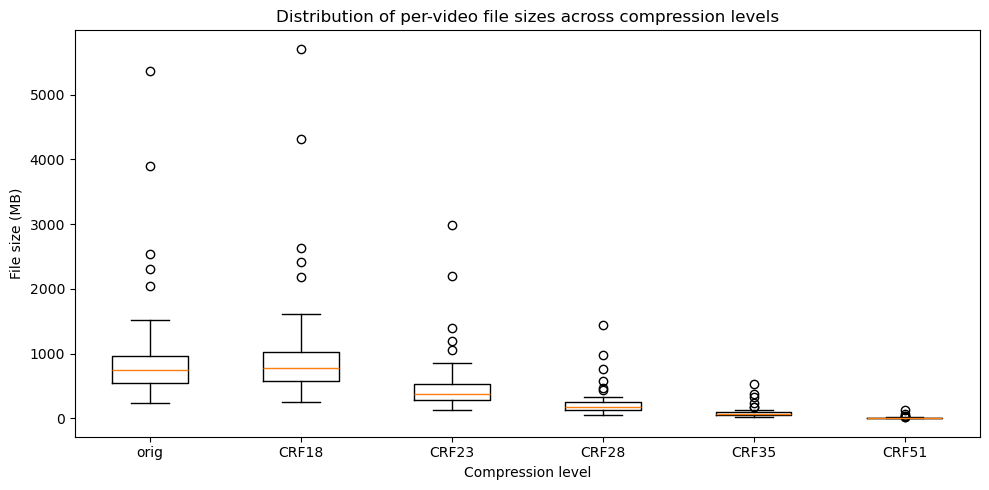

In [15]:
# ============================================================
# Plot 5: Distribution of per-video file sizes
# ============================================================
box_df = pd.DataFrame({
    "orig": df_sizes["orig_MB"],
    "CRF18": df_sizes["CRF18_MB"],
    "CRF23": df_sizes["CRF23_MB"],
    "CRF28": df_sizes["CRF28_MB"],
    "CRF35": df_sizes["CRF35_MB"],
    "CRF51": df_sizes["CRF51_MB"],
})

plt.figure(figsize=(10, 5))
plt.boxplot([box_df[col].dropna() for col in box_df.columns], labels=box_df.columns)
plt.ylabel("File size (MB)")
plt.xlabel("Compression level")
plt.title("Distribution of per-video file sizes across compression levels")
plt.tight_layout()
plt.show()

In [16]:
# ============================================================
# Visual table: per-video sizes
# ============================================================
styled_sizes = (
    df_per_video.set_index("video")
    .style
    .format("{:.2f}")
    .background_gradient(cmap="Blues")
)

styled_sizes

,orig_MB,CRF18_MB,CRF23_MB,CRF28_MB,CRF35_MB,CRF51_MB
video,,,,,,
video01.mp4,660.58,694.22,346.18,168.06,65.27,8.60
video02.mp4,1087.52,1146.51,591.30,296.11,116.04,16.20
video03.mp4,3900.07,4309.07,2205.55,981.17,324.99,42.43
video04.mp4,527.16,552.59,275.91,134.48,53.50,8.06
video05.mp4,815.98,857.33,418.98,201.69,81.33,13.17
video06.mp4,827.56,872.98,445.04,219.65,86.24,12.58
video07.mp4,2045.07,2187.94,1056.12,471.35,174.68,24.55
video08.mp4,408.27,428.68,210.62,105.14,44.93,7.40
video09.mp4,1028.37,1085.20,547.88,267.66,105.22,14.56


In [17]:
# ============================================================
# Visual table: per-video % reduction vs original
# ============================================================
styled_pct = (
    df_pct.set_index("video")
    .style
    .format("{:.2f}")
    .background_gradient(cmap="Greens")
)

styled_pct

,CRF18_pct_reduction,CRF23_pct_reduction,CRF28_pct_reduction,CRF35_pct_reduction,CRF51_pct_reduction
video,,,,,
video01.mp4,-5.09,47.59,74.56,90.12,98.70
video02.mp4,-5.42,45.63,72.77,89.33,98.51
video03.mp4,-10.49,43.45,74.84,91.67,98.91
video04.mp4,-4.83,47.66,74.49,89.85,98.47
video05.mp4,-5.07,48.65,75.28,90.03,98.39
video06.mp4,-5.49,46.22,73.46,89.58,98.48
video07.mp4,-6.99,48.36,76.95,91.46,98.80
video08.mp4,-5.00,48.41,74.25,88.99,98.19
video09.mp4,-5.53,46.72,73.97,89.77,98.58


In [18]:
# ============================================================
# Save tables
# ============================================================
out_dir = ROOT / "outputs" / "compression_storage_analysis"
out_dir.mkdir(parents=True, exist_ok=True)

df_sizes.to_csv(out_dir / "per_video_storage_comparison.csv", index=False)
df_per_video.to_csv(out_dir / "per_video_storage_comparison_MB.csv", index=False)
df_pct.to_csv(out_dir / "per_video_pct_reduction.csv", index=False)
df_summary.to_csv(out_dir / "compression_storage_summary.csv", index=False)

print("Saved outputs to:", out_dir)

Saved outputs to: cholec80/outputs/compression_storage_analysis


In [19]:
# ============================================================
# Auto-generated textual summary
# ============================================================
summary_for_text = df_summary_rounded.set_index("level")

orig_total = summary_for_text.loc["orig", "total_GB"]
print(f"Original dataset total size: {orig_total:.2f} GB\n")

for level in ["CRF18", "CRF23", "CRF28", "CRF35", "CRF51"]:
    avg_mb = summary_for_text.loc[level, "avg_MB"]
    total_gb = summary_for_text.loc[level, "total_GB"]
    avg_red = summary_for_text.loc[level, "avg_pct_reduction_vs_orig"]
    total_red = summary_for_text.loc[level, "total_pct_reduction_vs_orig"]
    
    print(
        f"{level}: average video size = {avg_mb:.2f} MB | "
        f"total storage = {total_gb:.2f} GB | "
        f"average reduction vs original = {avg_red:.2f}% | "
        f"total reduction vs original = {total_red:.2f}%"
    )

Original dataset total size: 69.78 GB

CRF18: average video size = 942.57 MB | total storage = 73.64 GB | average reduction vs original = -5.16% | total reduction vs original = -5.53%
CRF23: average video size = 467.68 MB | total storage = 36.54 GB | average reduction vs original = 48.27% | total reduction vs original = 47.64%
CRF28: average video size = 226.66 MB | total storage = 17.71 GB | average reduction vs original = 74.79% | total reduction vs original = 74.62%
CRF35: average video size = 90.50 MB | total storage = 7.07 GB | average reduction vs original = 89.82% | total reduction vs original = 89.87%
CRF51: average video size = 13.50 MB | total storage = 1.05 GB | average reduction vs original = 98.53% | total reduction vs original = 98.49%
